In [1]:
import os
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd


In [2]:
current_dir = Path.cwd()
data_dir = Path(current_dir, 'data.philiplessner.com')
path2processed = data_dir /'log_processed.csv'

In [3]:
df = pd.read_csv(path2processed, parse_dates=['datetime'], dtype={'status_Code': 'Int64', 'lat': 'Float64', 'lon': 'Float64'})

In [5]:
df.head()

,ip_address,datetime,request_type,endpoint,http_version,status_code,user_agent,Agent_Type,country,countryCode,region,regionName,city,zip,lat,lon,timezone
0,129.146.237.0,2026-07-12 11:11:43+00:00,GET,/blog/0,HTTP/1.1,200,Scrapy/2.16.0 (+https://scrapy.org),R,United States,US,AZ,Arizona,Phoenix,85008,33.4656,-111.9956,America/Phoenix
1,47.82.11.184,2026-07-12 11:12:43+00:00,GET,/robots.txt,HTTP/1.1,200,Mozilla/5.0 (Macintosh; Intel Mac OS X 10_15_7...,R,Singapore,SG,3,North West,Singapore,858877,1.35208,103.82,Asia/Singapore
2,47.82.11.184,2026-07-12 11:12:52+00:00,GET,/sitemap_news.xml.gz,HTTP/1.1,404,Mozilla/5.0 (Macintosh; Intel Mac OS X 10_15_7...,H,Singapore,SG,3,North West,Singapore,858877,1.35208,103.82,Asia/Singapore
3,40.77.167.144,2026-07-12 11:20:49+00:00,GET,/,HTTP/1.1,200,"Mozilla/5.0 AppleWebKit/537.36 (KHTML, like Ge...",R,United States,US,VA,Virginia,Boydton,23917,36.677696,-78.37471,America/New_York
4,17.241.227.225,2026-07-12 11:26:03+00:00,GET,/photos/france,HTTP/1.1,200,Mozilla/5.0 (Macintosh; Intel Mac OS X 10_15_7...,R,United States,US,CA,California,Cupertino,95014,37.3322,-122.011,America/Los_Angeles


In [6]:
groups = df.groupby('Agent_Type')

In [7]:
groups['ip_address'].count()

Agent_Type
H    1721
R    1700
Name: ip_address, dtype: int64

In [8]:
min_date = df['datetime'].min().strftime("%Y-%m-%d")
max_date = df['datetime'].max().strftime("%Y-%m-%d")

In [9]:
groups.get_group('H')

,ip_address,datetime,request_type,endpoint,http_version,status_code,user_agent,Agent_Type,country,countryCode,region,regionName,city,zip,lat,lon,timezone
2,47.82.11.184,2026-07-12 11:12:52+00:00,GET,/sitemap_news.xml.gz,HTTP/1.1,404,Mozilla/5.0 (Macintosh; Intel Mac OS X 10_15_7...,H,Singapore,SG,3,North West,Singapore,858877,1.35208,103.82,Asia/Singapore
5,154.159.252.207,2026-07-12 12:02:19+00:00,GET,/photos/australia,HTTP/1.1,200,Mozilla/5.0 (Macintosh; Intel Mac OS X 10_10) ...,H,Kenya,KE,30,Nairobi County,Nairobi,9831,-1.2841,36.8155,Africa/Nairobi
7,171.250.162.196,2026-07-12 12:35:37+00:00,GET,/,HTTP/1.1,200,Mozilla/5.0 (Macintosh; Intel Mac OS X 11_3_1)...,H,Vietnam,VN,SG,Ho Chi Minh,Ho Chi Minh City,700000,10.822,106.6257,Asia/Ho_Chi_Minh
8,190.62.87.242,2026-07-12 13:21:14+00:00,GET,/blog/0,HTTP/1.1,200,Mozilla/5.0 (Macintosh; Intel Mac OS X 10_15_6...,H,El Salvador,SV,SS,San Salvador Department,San Salvador,NaN,13.6927,-89.1917,America/El_Salvador
9,138.84.33.34,2026-07-12 14:59:35+00:00,GET,/,HTTP/1.1,200,Mozilla/5.0 (Windows NT 6.1; WOW64) AppleWebKi...,H,Chile,CL,RM,Santiago Metropolitan,Santiago,NaN,-33.4488,-70.6692,America/Santiago
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3410,34.96.52.107,2026-08-13 23:36:57+00:00,GET,/blog/4,HTTP/1.1,200,Mozilla/5.0 (X11; Linux x86_64) AppleWebKit/53...,H,United States,US,OR,Oregon,The Dalles,97058,45.5945,-121.1786,America/Los_Angeles
3411,151.241.239.35,2026-08-13 23:41:39+00:00,GET,/blog,HTTP/1.1,200,Mozilla/5.0 (Linux; Android 5.0; SM-G900P Buil...,H,Canada,CA,QC,Quebec,Alma,G8B,48.5506,-71.6479,America/Toronto
3418,201.175.68.141,2026-08-14 03:08:34+00:00,GET,/blog/9,HTTP/1.1,200,Mozilla/5.0 (Windows NT 10.0; Win64; x64) Appl...,H,Mexico,MX,NLE,Nuevo León,Monterrey,64200,25.6449,-100.311,America/Monterrey
3419,74.91.59.104,2026-08-14 03:25:15+00:00,GET,/blog,HTTP/1.1,200,Mozilla/5.0 (Macintosh; Intel Mac OS X 10_15) ...,H,United States,US,DC,District of Columbia,Washington,20001,38.9091,-77.0203,America/New_York


In [18]:
# 1. Convert your string boundaries into UTC-aware Timestamps
start_date = pd.Timestamp('2026-07-20 00:00:00').tz_localize('UTC')
end_date   = pd.Timestamp('2026-08-14 23:59:59').tz_localize('UTC')

# 3. Query the data and use .copy() to make it a completely new DataFrame
new_df = groups.get_group('H').query('@start_date <= datetime <= @end_date').copy()

In [19]:
counts_human = new_df.groupby('countryCode')['ip_address'].count().sort_values(ascending=False)

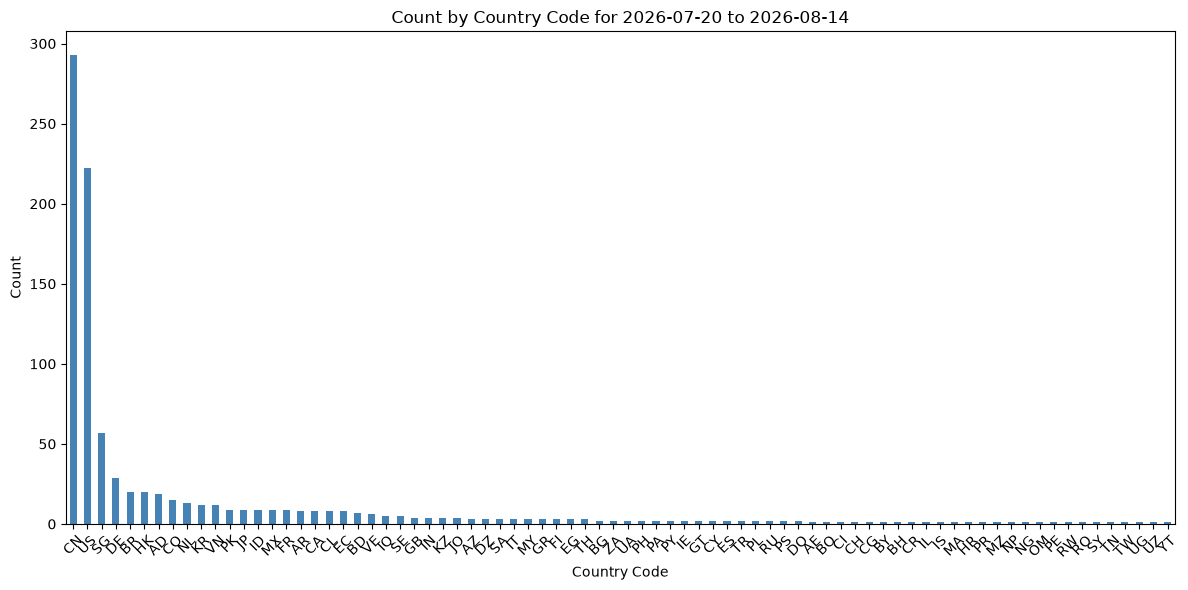

In [22]:
counts_human.plot(kind='bar', figsize=(12, 6), color='steelblue')
plt.title(f'Count by Country Code for {start_date:%Y-%m-%d} to {end_date:%Y-%m-%d}')
plt.xlabel('Country Code')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.tight_layout()

In [21]:
counts_human[:10]

countryCode
CN    293
US    222
SG     57
DE     29
BR     20
HK     20
AD     19
CO     15
NL     13
KR     12
Name: ip_address, dtype: int64

In [21]:
df_counts_human = counts_human.to_frame(name='count')

In [22]:
df_counts_human[:10]

,count
countryCode,
US,687
CN,306
SG,95
DE,54
FR,37
BR,37
HK,34
GB,33
CA,29


In [23]:
counts_endpoints = groups.get_group('H').groupby('endpoint')['ip_address'].count().sort_values(ascending=False)


In [24]:
df_counts_endpoints = counts_endpoints.to_frame(name='count')

In [25]:
df_counts_endpoints[:10]

,count
endpoint,
/blog/4,569
/blog/8,155
/,151
/blog/6,116
/blog,102
/blog/9,71
/blog/5,70
/aboutme,35
/login,28


In [20]:
status_404 = groups.get_group('H').groupby('status_code').get_group(404)

In [21]:
status_404.groupby('endpoint')['ip_address'].count().sort_values(ascending=False)

endpoint
/.git/config                   5
/wp-json/wp/v2/users           3
/ads.txt                       2
/.git/HEAD                     2
/.env                          1
/admin/.git/config             1
/administrator/                1
/api/.git/config               1
/app/.git/config               1
/_ignition/execute-solution    1
/asset-manifest.json           1
/assets/manifest.json          1
/backend/.git/config           1
/backup/.git/config            1
/dev/.git/config               1
/dist/manifest.json            1
/git/.git/config               1
/application/.git/config       1
/mail/.git/config              1
/manifest.json                 1
/media/system/js/core.js       1
/media/jui/js/jquery.min.js    1
/sitemap-index.xml             1
/sitemap_news.xml.gz           1
/sites/favicon.ico             1
/public/.git/config            1
/staging/.git/config           1
/static/manifest.json          1
/webpack-stats.json            1
/v2/.git/config                1
/

In [22]:
daily_human = groups.get_group('H').groupby(pd.Grouper(key='datetime', freq='D'))
daily_robots = groups.get_group('R').groupby(pd.Grouper(key='datetime', freq='D'))


In [23]:
daily_human_visits = daily_human['ip_address'].count()
daily_robot_visits = daily_robots['ip_address'].count()

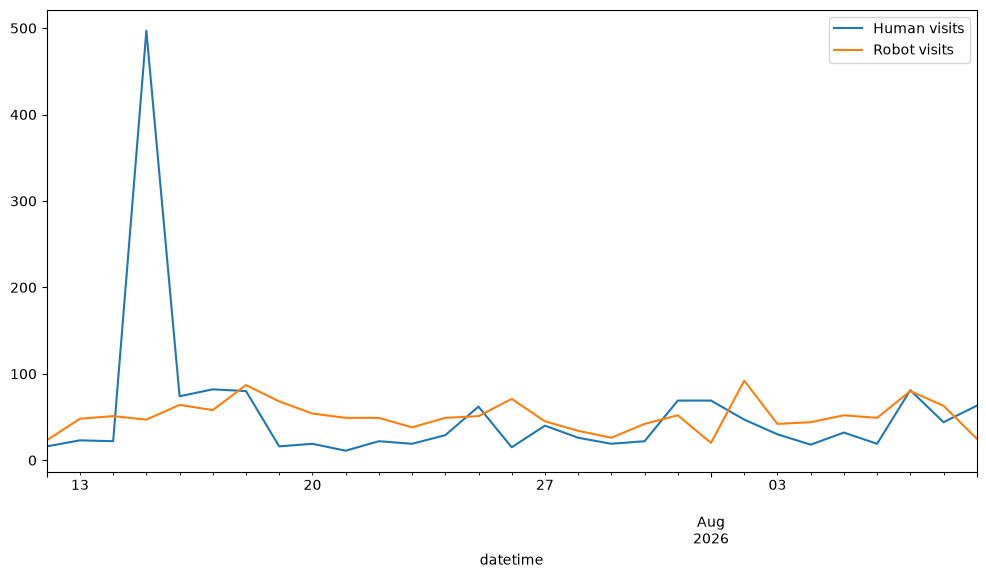

In [24]:
ax = daily_human_visits.plot(
    kind="line",
    figsize=(12, 6),
    label="Human visits",
)
daily_robot_visits.plot(
    kind="line",
    ax=ax,
    label="Robot visits",
)
ax.legend()